# Priorización de campañas bancarias antes del contacto
**Proyecto 1 — TFM MDATA2** · Diego Fernández · Octubre de 2026

Pregunta: ¿puede priorizarse la suscripción observada de depósitos a plazo con información disponible antes de llamar? Se utiliza Bank Marketing de UCI, descargado de Kaggle (41.188 registros reales). El objetivo es asociación predictiva, no uplift causal.

Este cuaderno ejecuta el pipeline completo y presenta sus resultados; el detalle de implementación está en `src/bank_marketing/`. No requiere conexión a internet al incluir el dataset comprimido con atribución CC BY 4.0.

In [1]:
from pathlib import Path
import sys, os, json, subprocess
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT / 'src/bank_marketing').exists(), 'Abrir desde la raíz del repositorio o notebooks/'
sys.path.insert(0, str(ROOT / 'src'))
os.environ['MPLCONFIGDIR'] = '/tmp/tfm-matplotlib'
os.environ['OMP_NUM_THREADS'] = '2'
subprocess.run([sys.executable, str(ROOT/'scripts/download_data.py')], check=True, capture_output=True, text=True)
data = pd.read_csv(ROOT/'data/raw/bank-additional-full.csv', sep=';')
display(data.head(5))
print(f'{data.shape[0]:,} registros, {data.shape[1]} columnas; suscripción {(data.y=="yes").mean():.2%}')

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


41,188 registros, 21 columnas; suscripción 11.27%


## Disponibilidad de variables y prevención de fuga
`duration` se conoce después de llamar. `campaign` incluye el último contacto. Canal, fecha de contacto e indicadores macroeconómicos se excluyen del modelo conservador por falta de información verificable sobre su disponibilidad prospectiva. Se conservan edad, características del cliente e historia de campañas previas. `pdays=999` significa ausencia de contacto anterior. Los valores `unknown` se mantienen explícitos.

Cada imputación, escalado y codificación se ajusta dentro del pipeline únicamente con entrenamiento. Las 12 filas idénticas se mantienen: sin identificador de cliente no se puede inferir que sean errores.

In [2]:
from bank_marketing.core import BankFeatures, RAW_FEATURES, FORBIDDEN, chronological_splits
features = BankFeatures().fit_transform(data.drop(columns='y'))
display(features.head())
assert not set(FORBIDDEN) & set(features.columns)
split = chronological_splits(len(data))
partition_table = pd.DataFrame([{'bloque':k, 'n':len(ix), 'primer_registro':ix[0], 'ultimo_registro':ix[-1], 'suscripcion':(data.iloc[ix].y=='yes').mean()} for k,ix in split.items()])
display(partition_table)

,age,job,marital,education,default,housing,loan,pdays,previous,poutcome,previously_contacted
0,56,housemaid,married,basic.4y,no,no,no,NaN,0,nonexistent,0
1,57,services,married,high.school,unknown,no,no,NaN,0,nonexistent,0
2,37,services,married,high.school,no,yes,no,NaN,0,nonexistent,0
3,40,admin.,married,basic.6y,no,no,no,NaN,0,nonexistent,0
4,56,services,married,high.school,no,no,yes,NaN,0,nonexistent,0


,bloque,n,primer_registro,ultimo_registro,suscripcion
0,train,24712,0,24711,0.048074
1,selection,4119,24712,28830,0.101481
2,calibration,4119,28831,32949,0.119932
3,test,8238,32950,41187,0.308327


## Entrenamiento, comparación y evaluación
Se comparan regresión logística, random forest y hist gradient boosting (dos configuraciones por familia), además de un dummy prior. La selección usa average precision en el siguiente 10% cronológico. La regresión ganadora se reajusta con el primer 70%; una calibración sigmoide usa el siguiente 10%. Ese bloque también decide un umbral contable hipotético. El último 20% se reserva para evaluación.

Se ejecuta además validación de origen móvil en tres cortes del primer 70%, sin usar la prueba. El orden es cronológico según UCI; no se dispone de fechas exactas ni ID de cliente. Los cortes por número de filas no representan intervalos temporales de igual duración.

In [3]:
env = dict(os.environ, PYTHONPATH=str(ROOT/'src'), OMP_NUM_THREADS='2')
run = subprocess.run([sys.executable, '-m', 'bank_marketing.run', '--root', str(ROOT)], cwd=ROOT, env=env, capture_output=True, text=True, check=True)
print(run.stdout)
results = json.loads((ROOT/'reports/results.json').read_text())
display(pd.read_csv(ROOT/'reports/tables/model_selection.csv')[['model','average_precision','roc_auc','brier','lift_at_10pct']])
display(pd.read_csv(ROOT/'reports/tables/forward_validation.csv')[['fold','prevalence','average_precision','roc_auc','lift_at_10pct']])

,model,average_precision,roc_auc,brier,lift_at_10pct
0,logistic_C1,0.149747,0.593693,0.094156,1.745988
1,logistic_C0.1,0.148972,0.586877,0.094237,1.841658
2,hist_gradient_leaf15,0.130020,0.568152,0.093487,1.315470
3,hist_gradient_leaf31,0.121966,0.550362,0.093622,1.315470
4,random_forest_leaf30,0.116667,0.541964,0.093654,1.267635
5,random_forest_leaf10,0.107396,0.517234,0.094361,1.171964
6,dummy_prior,0.101481,0.500000,0.094035,1.000000


,fold,prevalence,average_precision,roc_auc,lift_at_10pct
0,1,0.047454,0.051391,0.511999,0.818373
1,2,0.064104,0.066466,0.512773,1.103437
2,3,0.081865,0.088647,0.545548,0.864047


Validated dummy_prior: AP=0.1015
Validated logistic_C0.1: AP=0.1490
Validated logistic_C1: AP=0.1497
Validated random_forest_leaf10: AP=0.1074
Validated random_forest_leaf30: AP=0.1167
Validated hist_gradient_leaf15: AP=0.1300
Validated hist_gradient_leaf31: AP=0.1220
{
  "n": 8238,
  "prevalence": 0.3083272638990046,
  "roc_auc": 0.6144930670521221,
  "average_precision": 0.4465988009477883,
  "brier": 0.23048037003584718,
  "precision": 0.30732600732600734,
  "recall": 0.9909448818897638,
  "f1": 0.46915191053122085,
  "threshold": 0.05469798657718121,
  "precision_at_10pct": 0.5740291262135923,
  "recall_at_10pct": 0.1862204724409449,
  "lift_at_10pct": 1.8617527329714854
}
Completed evidence: reports/ and local models/



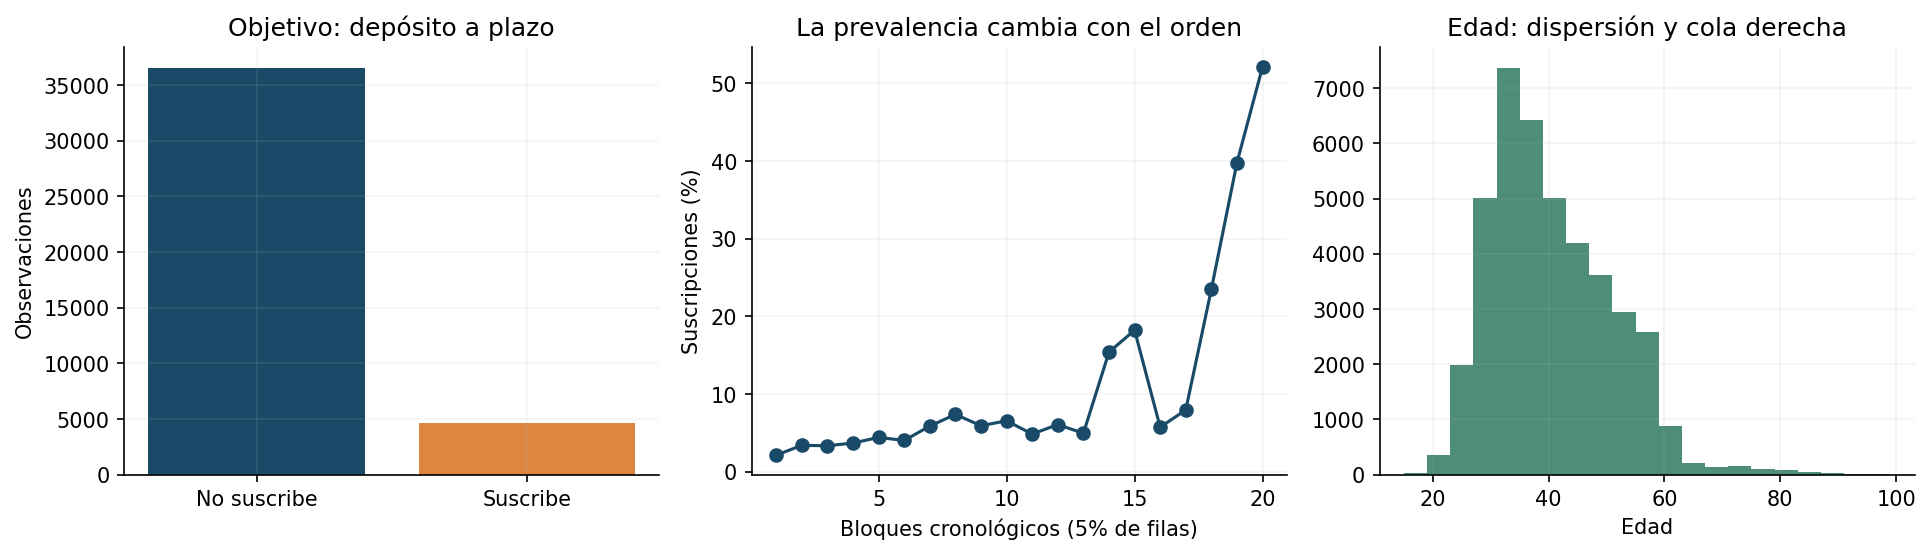

,model,training_scope,average_precision,roc_auc,brier,precision_at_10pct,lift_at_10pct
0,dummy_prior,initial 60%; benchmark only,0.308327,0.500000,0.280993,0.308327,1.000000
1,logistic_C0.1,initial 60%; benchmark only,0.425345,0.560321,0.255867,0.667476,2.164829
2,logistic_C1,initial 60%; benchmark only,0.421987,0.560104,0.261526,0.651699,2.113660
3,random_forest_leaf10,initial 60%; benchmark only,0.318124,0.521487,0.277422,0.308252,0.999757
4,random_forest_leaf30,initial 60%; benchmark only,0.330391,0.533585,0.277269,0.343447,1.113903
5,hist_gradient_leaf15,initial 60%; benchmark only,0.328119,0.516742,0.278628,0.373786,1.212304
6,hist_gradient_leaf31,initial 60%; benchmark only,0.326827,0.522481,0.278436,0.342233,1.109967
7,logistic_C1_refit_uncalibrated,first 70%,0.446599,0.614493,0.255257,0.574029,1.861753
8,logistic_C1_refit_sigmoid,first 70%; calibration next 10%,0.446599,0.614493,0.230480,0.574029,1.861753


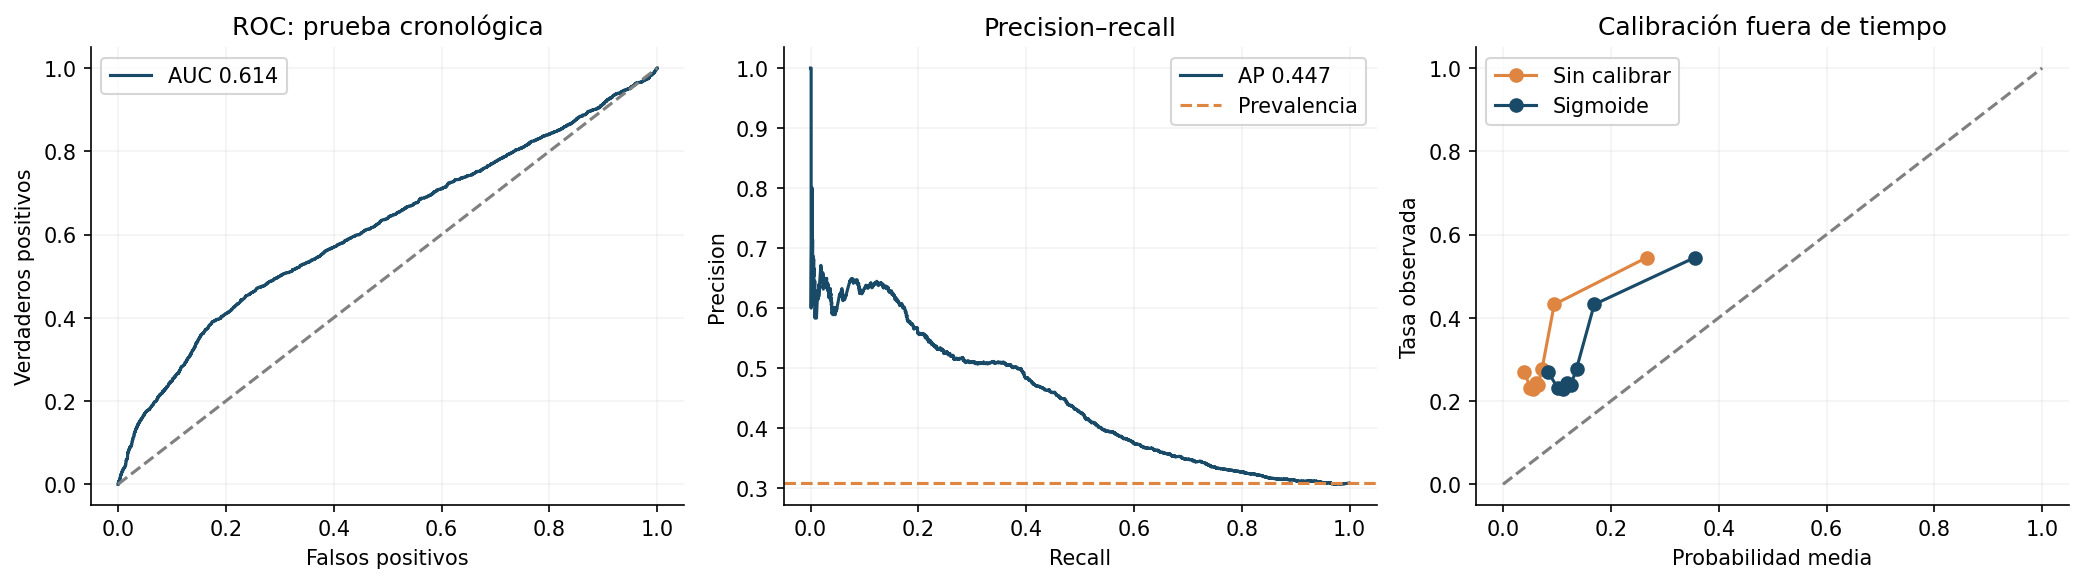

In [4]:
display(Image(filename=str(ROOT/'reports/figures/01_data_overview.png')))
display(pd.read_csv(ROOT/'reports/tables/test_metrics.csv')[['model','training_scope','average_precision','roc_auc','brier','precision_at_10pct','lift_at_10pct']])
display(Image(filename=str(ROOT/'reports/figures/03_model_evaluation.png')))

## Interpretación crítica
La prevalencia pasa de 4,81% en entrenamiento a 30,83% en prueba. El ranking del modelo final concentra un 57,40% de aceptaciones observadas en el 10% priorizado, frente a 30,83% esperado al azar (lift 1,86). Sin embargo, la validación móvil no demuestra estabilidad: dos de tres ventanas tienen lift inferior a uno.

La calibración reduce Brier de 0,2553 a 0,2305, pero el cambio temporal persiste. Una constante ajustada con la prevalencia del propio test alcanzaría Brier 0,2133; es un diagnóstico retrospectivo que no puede conocerse al desplegar. No se afirma que el modelo esté listo para producción. El dummy, al empatar todos sus scores, muestra expectativas de selección aleatoria en métricas top-k.

,metric,lower_95,upper_95,method,replications
0,roc_auc,0.602002,0.628071,row bootstrap; conditional/descriptive,250
1,average_precision,0.427409,0.469116,row bootstrap; conditional/descriptive,250
2,brier,0.223424,0.237304,row bootstrap; conditional/descriptive,250
3,precision_at_10pct,0.541262,0.608010,row bootstrap; conditional/descriptive,250
4,lift_at_10pct,1.766049,1.972628,row bootstrap; conditional/descriptive,250


,policy,contacts,observed_acceptances_in_selected,precision_selected,proxy_profit,benefit_assumption,cost_assumption
0,Nadie,0,0.000000,0.000000,0.000000,100.0,5.0
1,Todos,8238,2540.000000,0.308327,212810.000000,100.0,5.0
2,Top 10% (presupuesto fijo),824,473.000000,0.574029,43180.000000,100.0,5.0
3,Umbral validado,8190,2517.000000,0.307326,210750.000000,100.0,5.0
4,Umbral teórico coste/beneficio,8204,2526.000000,0.307899,211580.000000,100.0,5.0
5,Aleatorio 10% (valor esperado),824,254.061665,0.308327,21286.166545,100.0,5.0


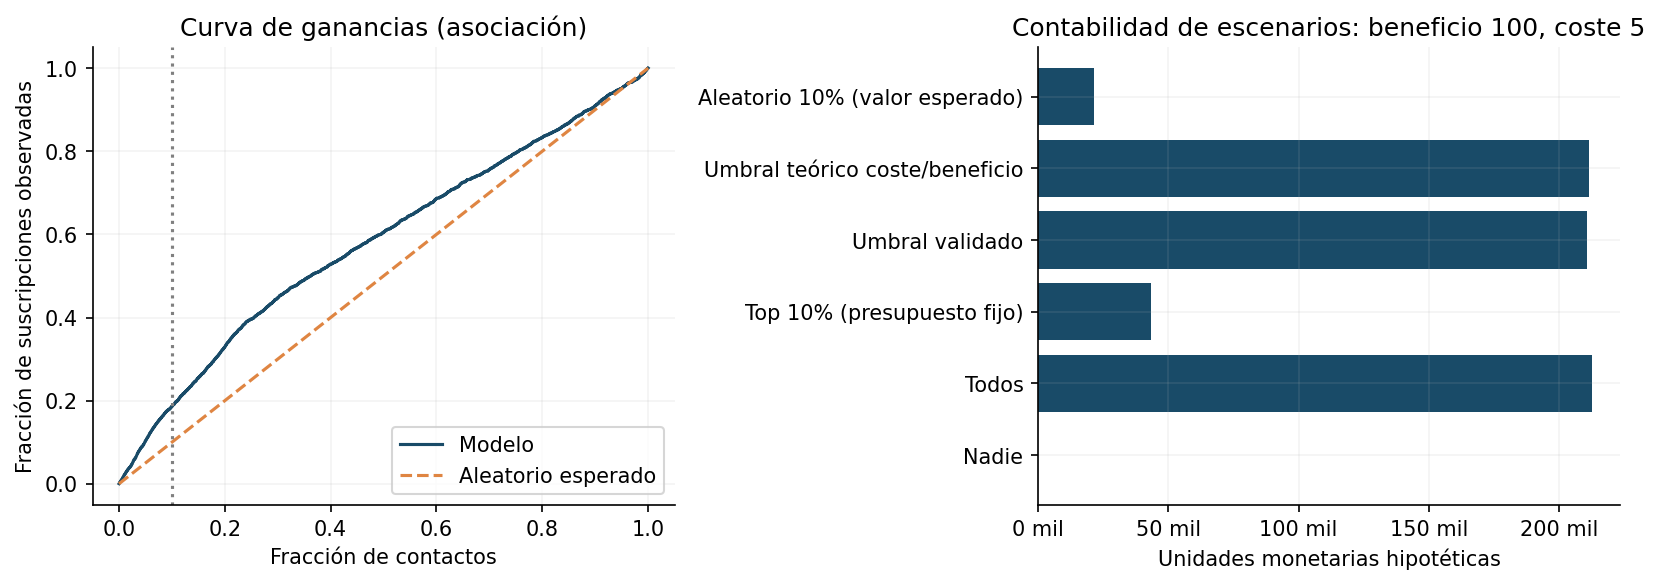

In [5]:
display(pd.read_csv(ROOT/'reports/tables/bootstrap_intervals.csv'))
display(pd.read_csv(ROOT/'reports/tables/business_scenarios.csv'))
display(Image(filename=str(ROOT/'reports/figures/04_policy_scenarios.png')))

## Decisión de negocio y sensibilidad
Se usa un beneficio supuesto de 100 unidades por aceptación observada y coste de 5 por contacto. Con presupuesto de 824 contactos, el top 10% obtiene una proxy contable de 43.180, frente a 21.286 al azar. Son escenarios, no ganancias incrementales identificadas. Sin límite de capacidad, contactar a todos obtiene una proxy mayor (212.810), porque los supuestos hacen rentables muchas aceptaciones. La política depende de capacidad y costes; ranking y umbral responden a preguntas distintas.

Los intervalos bootstrap son condicionales y descriptivos: remuestrear filas no resuelve la dependencia temporal ni contactos repetidos de clientes.

In [6]:
display(pd.read_csv(ROOT/'reports/tables/cost_benefit_sensitivity.csv').head(8))
display(pd.read_csv(ROOT/'reports/tables/permutation_importance.csv'))
display(pd.read_csv(ROOT/'reports/tables/age_group_audit.csv'))

,benefit,contact_cost,top_10pct_proxy_profit,random_10pct_expected_proxy_profit,all_proxy_profit
0,25,2,10177.0,4703.541636,47024.0
1,25,5,7705.0,2231.541636,22310.0
2,25,10,3585.0,-1888.458364,-18880.0
3,25,20,-4655.0,-10128.458364,-101260.0
4,50,2,22002.0,11055.083273,110524.0
5,50,5,19530.0,8583.083273,85810.0
6,50,10,15410.0,4463.083273,44620.0
7,50,20,7170.0,-3776.916727,-37760.0


,feature,mean_ap_drop,std_ap_drop
0,pdays,0.111894,0.003702
1,poutcome,0.054192,0.002814
2,job,0.033293,0.003834
3,education,0.005652,0.001133
4,default,0.004373,0.000687
5,loan,0.000146,0.000090
6,housing,-0.000041,0.000293
7,marital,-0.002847,0.001267
8,age,-0.005673,0.001722
9,previous,-0.014667,0.001991


,age_group,n,observed_prevalence,selection_rate,precision_selected,recall_selected,brier
0,<30,1945,0.302314,0.196915,0.488251,0.318027,0.215930
1,30–44,3792,0.272416,0.064610,0.624490,0.148112,0.209268
2,45–59,1655,0.320846,0.058610,0.608247,0.111111,0.249217
3,60+,846,0.458629,0.117021,0.747475,0.190722,0.322359


## Explicabilidad y uso responsable
La importancia por permutación mide contribución predictiva y no causalidad. Las curvas de dependencia parcial pueden crear combinaciones que no representan clientes reales. El uso de edad, ocupación y educación puede producir diferencias de selección; la auditoría por grupos de edad es exploratoria y no certifica equidad. El dataset no tiene sexo, etnia, consentimiento, montos ni margen de los depósitos.

Antes de cualquier implementación se necesita una base reciente con IDs, disponibilidad temporal auditada y consentimiento, una política de contactos, evaluación temporal y por clientes, monitorización y prueba prospectiva de decisiones. El despliegue conceptual y los criterios se desarrollan en `reports/INFORME.md`.

In [7]:
# Ejemplo reproducible de inferencia local; el modelo se genera al entrenar.
import joblib
model = joblib.load(ROOT/'models/bank_marketing.joblib')
example = data.iloc[-5:][RAW_FEATURES].copy()
example['score_suscripcion'] = model.predict_proba(example)[:,1]
display(example)
tests = subprocess.run([sys.executable, '-m', 'pytest', '-q'], cwd=ROOT, env=env, capture_output=True, text=True, check=True)
print(tests.stdout)

,age,job,marital,education,default,housing,loan,pdays,previous,poutcome,score_suscripcion
41183,73,retired,married,professional.course,no,yes,no,999,0,nonexistent,0.167485
41184,46,blue-collar,married,professional.course,no,no,no,999,0,nonexistent,0.102036
41185,56,retired,married,university.degree,no,yes,no,999,0,nonexistent,0.203807
41186,44,technician,married,professional.course,no,no,no,999,0,nonexistent,0.098344
41187,74,retired,married,professional.course,no,yes,no,999,1,failure,0.174822


.......                                                                  [100%]
7 passed in 1.42s



## Fuentes y autoría
- Kaggle: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv (Sahista_Patel).
- UCI, fuente primaria y licencia CC BY 4.0: https://doi.org/10.24432/C5K306.
- Moro, Cortez y Rita (2014), *A Data-Driven Approach to Predict the Success of Bank Telemarketing*, Decision Support Systems 62, 22–31.
- Documentación oficial scikit-learn: pipelines, calibración, average precision y TimeSeriesSplit.

Autor: Diego Fernández. Elaboración y programación asistidas por inteligencia artificial; resultados calculados con datos reales, código reproducible y pruebas automáticas. La interpretación y revisión académica final corresponden al autor.